# Predicting Superconducting Critical Temperature with Machine Learning

This project explores machine learning approaches for predicting the critical temperature `critical_temp` of superconducting materials using engineered material descriptors. The goal is to compare several regression models (including a deep neural network), evaluate their predictive performance with cross-validation, and investigate which features appear most informative for the prediction task.

## Motivation

Superconducting materials are important for advanced physics and materials science because they can exhibit unusual electronic behavior and may enable future technologies. Predicting critical temperature `Tc` from material descriptors can help build an early screening pipeline for identifying promising superconducting candidates before more expensive analysis or experiments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dataset

The dataset contains engineered descriptors of superconducting materials and the target variable `critical_temp` (in Kelvin). These descriptors are numerical features derived from elemental and compositional properties (atomic mass, valence, thermal conductivity, electron affinity, atomic radius, fusion heat) and are used as inputs for regression models. Source: UCI Machine Learning Repository / Hamidieh (2018).

In [2]:
import os
path = "train.csv" if os.path.exists("train.csv") else "/content/train.csv"
df = pd.read_csv(path, engine="python", on_bad_lines="skip")
print("Loaded shape:", df.shape)

Loaded shape: (21263, 82)


## Preprocessing

The dataset was cleaned before modeling. The column `wtd_std_Density` was coerced to a numeric type, and rows containing invalid or missing values were removed. The target variable was defined as `critical_temp`, and all remaining numerical descriptors were used as input features.

In [3]:
df["wtd_std_Density"] = pd.to_numeric(df["wtd_std_Density"], errors="coerce")

In [4]:
df = df.dropna().reset_index(drop=True)

In [5]:
y = df["critical_temp"]
X = df.drop(columns=["critical_temp"])
print("Rows after cleaning:", len(df))
print("Number of features:", X.shape[1])

Rows after cleaning: 21263
Number of features: 81


## Train-Test Split

The cleaned dataset was split into training (80%) and test (20%) sets with a fixed random seed. The training set was used to fit the models, while the held-out test set was used to evaluate predictive performance on unseen data.

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Models

Six regression models were trained and compared:
- Linear Regression (baseline)
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor
- Multilayer Perceptron (deep neural network, PyTorch)

Models were compared using MAE, MSE, RMSE and R^2 on the test set, and using 5-fold cross-validated RMSE (mean +/- std) on the training set.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

cv_scores_lr = cross_val_score(model, x_train, y_train, cv=cv,
                               scoring="neg_root_mean_squared_error", n_jobs=1)
cv_rmse_lr = -cv_scores_lr.mean()
cv_std_lr = cv_scores_lr.std()

In [10]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(x_train, y_train)
y_pred_tree = tree_model.predict(x_test)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

cv_scores_tree = cross_val_score(tree_model, x_train, y_train, cv=cv,
                                 scoring="neg_root_mean_squared_error", n_jobs=1)
cv_rmse_tree = -cv_scores_tree.mean()
cv_std_tree = cv_scores_tree.std()

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42, n_estimators=300, n_jobs=-1)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

cv_scores_rf = cross_val_score(rf_model, x_train, y_train, cv=cv,
                               scoring="neg_root_mean_squared_error", n_jobs=1)
cv_rmse_rf = -cv_scores_rf.mean()
cv_std_rf = cv_scores_rf.std()

In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

cv_scores_gb = cross_val_score(gb_model, x_train, y_train, cv=cv,
                               scoring="neg_root_mean_squared_error", n_jobs=1)
cv_rmse_gb = -cv_scores_gb.mean()
cv_std_gb = cv_scores_gb.std()

In [13]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42, n_estimators=300, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", n_jobs=-1)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

cv_scores_xgb = cross_val_score(xgb_model, x_train, y_train, cv=cv,
                                scoring="neg_root_mean_squared_error", n_jobs=1)
cv_rmse_xgb = -cv_scores_xgb.mean()
cv_std_xgb = cv_scores_xgb.std()

## Deep Learning Model (Multilayer Perceptron)

In addition to the classical models, a deep neural network (multilayer perceptron, MLP) was implemented in PyTorch. The network has three hidden layers (256-128-64) with batch normalization, ReLU activations and dropout regularization. Inputs and the target were standardized using training-set statistics, the network was trained with the Adam optimizer and mean-squared-error loss, and early stopping on an internal validation split was used to prevent overfitting. The same 5-fold cross-validation protocol as the other models was applied.

In [14]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Use Apple-Silicon GPU (MPS) when available, else CUDA, else CPU
device = torch.device("mps" if torch.backends.mps.is_available()
                      else ("cuda" if torch.cuda.is_available() else "cpu"))
torch.manual_seed(42)

class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        return self.net(x)

def train_mlp(X_tr, y_tr, X_pred, seed=42, max_epochs=80, patience=10):
    torch.manual_seed(seed); np.random.seed(seed)
    xs = StandardScaler().fit(X_tr)
    mu, sd = y_tr.mean(), y_tr.std()
    Xt = torch.tensor(xs.transform(X_tr), dtype=torch.float32)
    yt = torch.tensor(((y_tr - mu) / sd).values, dtype=torch.float32).view(-1, 1)
    n = len(Xt); idx = np.random.permutation(n); cut = int(0.85 * n)
    tri, vai = idx[:cut], idx[cut:]
    Xa, ya = Xt[tri].to(device), yt[tri].to(device)
    Xv, yv = Xt[vai].to(device), yt[vai].to(device)
    m = MLP(X_tr.shape[1]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    lossf = nn.MSELoss(); bs = 1024; best = 1e9; best_state = None; bad = 0
    for _ in range(max_epochs):
        m.train(); perm = torch.randperm(len(Xa), device=device)
        for i in range(0, len(Xa), bs):
            b = perm[i:i+bs]; opt.zero_grad()
            loss = lossf(m(Xa[b]), ya[b]); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vl = lossf(m(Xv), yv).item()
        if vl < best - 1e-5:
            best, best_state, bad = vl, {k: v.clone() for k, v in m.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state:
        m.load_state_dict(best_state)
    m.eval()
    with torch.no_grad():
        pr = m(torch.tensor(xs.transform(X_pred), dtype=torch.float32).to(device)).cpu().numpy().ravel()
    return pr * sd + mu

print('Using device:', device)

Using device: mps


In [15]:
y_pred_mlp = train_mlp(x_train, y_train, x_test)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

mlp_cv = []
for tr_i, va_i in cv.split(x_train):
    p = train_mlp(x_train.iloc[tr_i], y_train.iloc[tr_i], x_train.iloc[va_i])
    mlp_cv.append(np.sqrt(mean_squared_error(y_train.iloc[va_i], p)))
cv_rmse_mlp = float(np.mean(mlp_cv))
cv_std_mlp = float(np.std(mlp_cv))
print(f"MLP  RMSE={rmse_mlp:.3f}  R2={r2_mlp:.4f}  CV_RMSE={cv_rmse_mlp:.3f} +/- {cv_std_mlp:.3f}")

MLP  RMSE=11.797  R2=0.8791  CV_RMSE=12.173 +/- 0.226


## Results Table

The performance metrics for all six models were collected into a single summary table, sorted by cross-validated RMSE (lower is better).

In [16]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest",
              "Gradient Boosting", "XGBoost", "MLP (Deep Learning)"],
    "MAE": [mae, mae_tree, mae_rf, mae_gb, mae_xgb, mae_mlp],
    "MSE": [mse, mse_tree, mse_rf, mse_gb, mse_xgb, mse_mlp],
    "RMSE": [rmse, rmse_tree, rmse_rf, rmse_gb, rmse_xgb, rmse_mlp],
    "R2": [r2, r2_tree, r2_rf, r2_gb, r2_xgb, r2_mlp],
    "CV_RMSE": [cv_rmse_lr, cv_rmse_tree, cv_rmse_rf, cv_rmse_gb, cv_rmse_xgb, cv_rmse_mlp],
    "CV_STD": [cv_std_lr, cv_std_tree, cv_std_rf, cv_std_gb, cv_std_xgb, cv_std_mlp],
})
results_df = results_df.sort_values(by="CV_RMSE").reset_index(drop=True)
results_df.round(3)

                 Model     MAE      MSE    RMSE     R2  CV_RMSE  CV_STD
0        Random Forest   5.076   80.452   8.970  0.930    9.700   0.253
1              XGBoost   5.811   86.037   9.276  0.925    9.876   0.280
2  MLP (Deep Learning)   7.697  139.165  11.797  0.879   12.173   0.226
3        Decision Tree   6.090  139.449  11.809  0.879   12.539   0.296
4    Gradient Boosting   8.501  152.150  12.335  0.868   12.794   0.149
5    Linear Regression  13.211  302.008  17.378  0.738   17.699   0.253

## Model Comparison

Random Forest achieved the best overall performance, closely followed by XGBoost; the two tree ensembles are statistically very close under cross-validation. The deep MLP performed in the middle of the field: it improved on the linear baseline, a single Decision Tree and Gradient Boosting, but did not match the two leading tree ensembles. Linear Regression was the weakest model by a wide margin. This pattern indicates that the relationship between engineered descriptors and critical temperature is strongly nonlinear, and that tree-based ensembles remain especially well suited to this tabular prediction task.

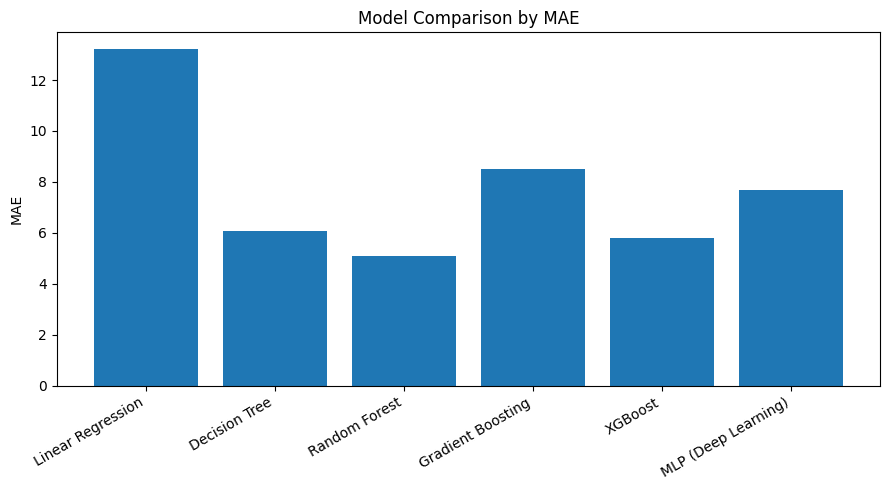

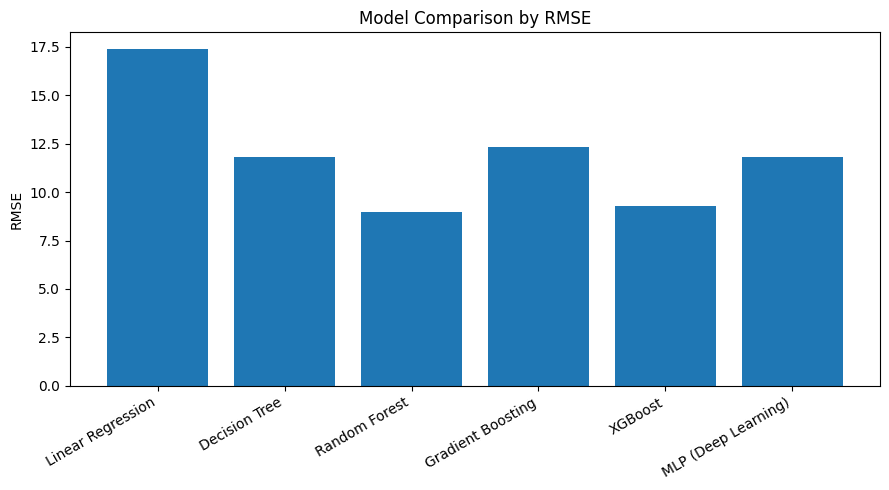

In [17]:
models = ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "MLP (Deep Learning)"]
mae_scores = [mae, mae_tree, mae_rf, mae_gb, mae_xgb, mae_mlp]
rmse_scores = [rmse, rmse_tree, rmse_rf, rmse_gb, rmse_xgb, rmse_mlp]

plt.figure(figsize=(9, 5))
plt.bar(models, mae_scores)
plt.ylabel('MAE')
plt.title('Model Comparison by MAE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(models, rmse_scores)
plt.ylabel('RMSE')
plt.title('Model Comparison by RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Feature Importance

Impurity-based feature importances were extracted from the Random Forest model to see which descriptors the best-performing model relied on most.

In [18]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance.head(15))

range_ThermalConductivity          0.536164
wtd_gmean_ThermalConductivity      0.125979
std_atomic_mass                    0.022212
wtd_gmean_Valence                  0.018727
std_Density                        0.011493
mean_Density                       0.010950
wtd_entropy_ThermalConductivity    0.010795
gmean_ElectronAffinity             0.010637
wtd_mean_Valence                   0.010394
wtd_std_ThermalConductivity        0.009820
wtd_std_ElectronAffinity           0.009744
wtd_range_Valence                  0.009514
wtd_std_Valence                    0.009007
wtd_range_atomic_mass              0.008959
wtd_mean_ThermalConductivity       0.008723
dtype: float64


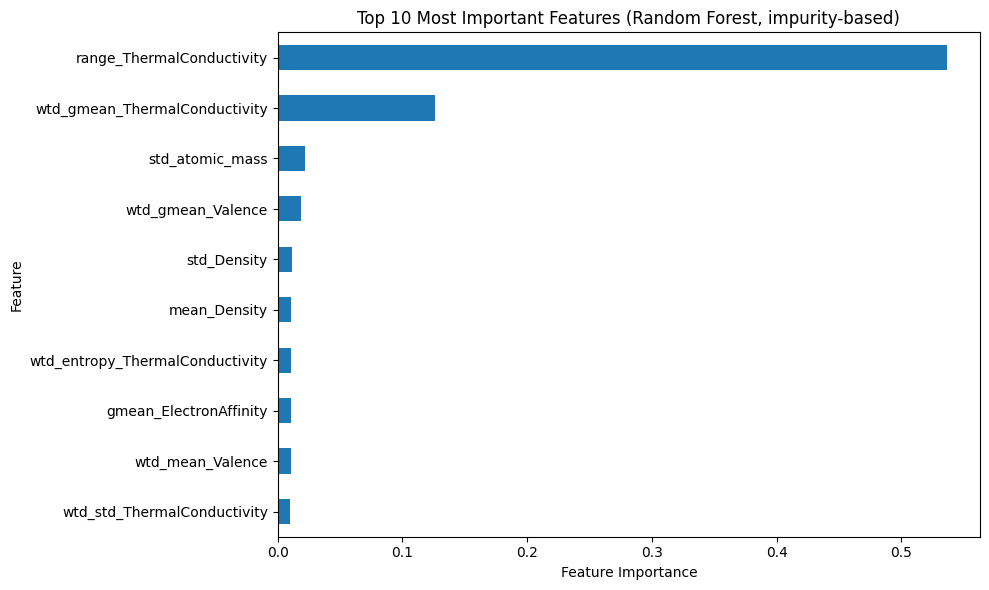

In [19]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features (Random Forest, impurity-based)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Permutation Importance (Robustness Check)

Impurity-based importances can be biased when features are correlated (many descriptors here are derived from the same underlying property, e.g. thermal conductivity). As a more reliable check, permutation importance was computed on the held-out test set: each feature is randomly shuffled and the increase in error is measured. A feature that is truly informative causes a large error increase when permuted.

In [20]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_model, x_test, y_test, n_repeats=5, random_state=42, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_imp.head(10))

range_ThermalConductivity        0.721966
wtd_gmean_ThermalConductivity    0.079345
std_atomic_mass                  0.038616
wtd_gmean_Valence                0.032992
mean_Density                     0.018098
entropy_FusionHeat               0.015216
entropy_Density                  0.014110
range_atomic_radius              0.014020
std_Density                      0.013744
wtd_std_ElectronAffinity         0.010606
dtype: float64


## Interpretation of Important Features

Both importance measures agree that a single descriptor, `range_ThermalConductivity`, dominates, followed by `wtd_gmean_ThermalConductivity` and atomic-mass-, valence- and density-related descriptors. The agreement between impurity-based and permutation importance strengthens confidence in this ranking. However, feature importance should not be read as proof of a causal physical relationship; it only reflects which features were most useful to the model, and thermal-conductivity descriptors are strongly correlated with one another.

## Correlation Analysis

In addition to model-based importance, Pearson correlation coefficients between each descriptor and `critical_temp` were computed across the full cleaned dataset.

In [21]:
corr_with_target = df.corr(numeric_only=True)["critical_temp"].sort_values(ascending=False)
print(corr_with_target.head(15))
print(corr_with_target.tail(15))

critical_temp                  1.000000
wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
wtd_std_atomic_radius          0.599199
entropy_Valence                0.598591
wtd_entropy_Valence            0.589664
wtd_std_fie                    0.582013
entropy_fie                    0.567817
wtd_entropy_FusionHeat         0.563244
Name: critical_temp, dtype: float64
gmean_ElectronAffinity      -0.380568
mean_FusionHeat             -0.385509
gmean_ThermalConductivity   -0.387192
wtd_mean_FusionHeat         -0.394117
wtd_gmean_atomic_radius     -0.405176
gmean_FusionHeat            -0.431795
wtd_gmean_FusionHeat        -0.432365
wtd_mean_Density            -0.433940
wtd_range_Valence           -0.439901
wtd_gmean_Density     

## Interpretation of Correlations

The strongest positive correlations involve thermal-conductivity-, atomic-radius- and entropy-related descriptors (`wtd_std_ThermalConductivity` r=0.72, `range_ThermalConductivity` r=0.69, `range_atomic_radius` r=0.65). The strongest negative correlations are valence- and density-related (`wtd_mean_Valence` r=-0.63). These associations are broadly consistent with the Random Forest importance ranking, although correlation alone does not establish physical causality.

## Distribution of the Target Variable

The distribution of `critical_temp` was visualized with a histogram to understand the target better.

mean=34.4  median=20.0  max=185.0  skew=0.86


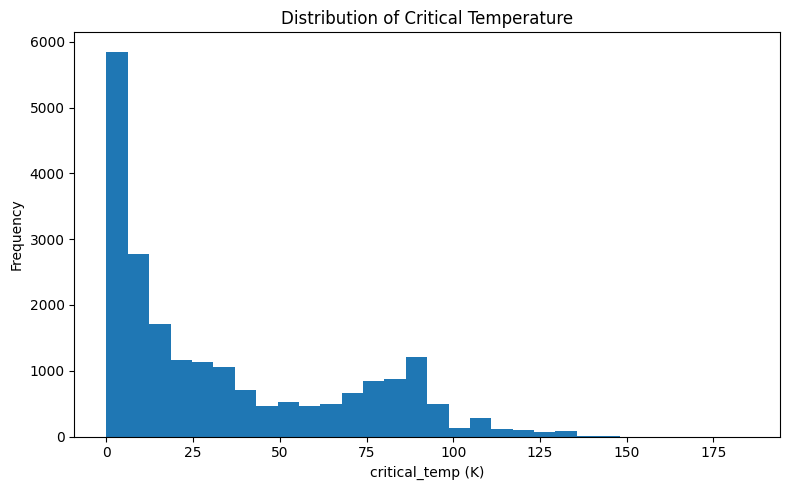

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df['critical_temp'], bins=30)
plt.xlabel('critical_temp (K)')
plt.ylabel('Frequency')
plt.title('Distribution of Critical Temperature')
plt.tight_layout()
plt.show()
print('mean=%.1f  median=%.1f  max=%.1f  skew=%.2f' % (
    df['critical_temp'].mean(), df['critical_temp'].median(),
    df['critical_temp'].max(), df['critical_temp'].skew()))

## Interpretation of Target Distribution

The distribution of `critical_temp` is right-skewed: most materials have relatively low critical temperatures, with a long tail of fewer high-Tc materials (up to 185 K). This asymmetry means the RMSE is dominated by the harder-to-predict high-Tc tail, and suggests the dataset may contain several material regimes.

## PCA Visualization

Principal Component Analysis (PCA) reduced the standardized 81-dimensional feature space to two dimensions for visualization. This does not replace the original features but helps inspect whether the dataset has visible structure related to the target.

Explained variance ratio: [0.38931798 0.10482209]
Total explained variance: 0.49414007043465685


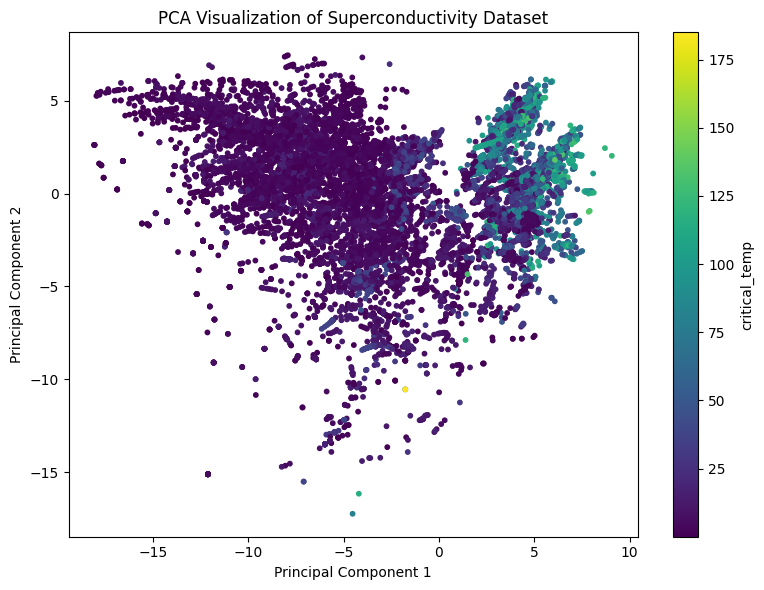

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['critical_temp'] = y.values

plt.figure(figsize=(8, 6))
sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['critical_temp'], s=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Superconductivity Dataset')
plt.colorbar(sc, label='critical_temp')
plt.tight_layout()
plt.show()

## Interpretation of PCA

The two-dimensional PCA projection explains about 49% of the total variance (PC1 39%, PC2 10%). Materials with higher critical temperatures cluster in specific regions rather than being uniformly distributed, indicating that the engineered descriptors carry structure related to `critical_temp`. The moderate explained variance shows this 2-D view captures only part of the dataset's complexity.

## Data Leakage / Duplicate Analysis

The superconductivity dataset is known to contain many near-identical compositions. A random train-test split can place near-duplicate materials in both the training and test sets, which leaks information and can make test performance look optimistic. As a robustness check, exact-duplicate feature rows were counted, and the best model (Random Forest) was re-evaluated after removing them.

In [24]:
n_dup = int(X.duplicated().sum())
print(f'Exact-duplicate feature rows: {n_dup} of {len(X)} ({100*n_dup/len(X):.1f}%)')

mask = ~X.duplicated(keep='first')
X_u, y_u = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
xtr_u, xte_u, ytr_u, yte_u = train_test_split(X_u, y_u, test_size=0.2, random_state=42)
rf_u = RandomForestRegressor(random_state=42, n_estimators=300, n_jobs=-1).fit(xtr_u, ytr_u)
p_u = rf_u.predict(xte_u)
print(f'Unique rows: {len(X_u)}')
print(f'RF on deduplicated data: RMSE={np.sqrt(mean_squared_error(yte_u, p_u)):.3f}  R2={r2_score(yte_u, p_u):.4f}')
print(f'RF on full data:         RMSE={rmse_rf:.3f}  R2={r2_rf:.4f}')

Exact-duplicate feature rows: 6093 of 21263 (28.7%)
Unique rows: 15170
RF on deduplicated data: RMSE=10.011  R2=0.9112
RF on full data:         RMSE=8.970  R2=0.9301


## Limitations

- The dataset uses engineered statistical descriptors rather than direct experimental or first-principles physical measurements, which limits physical interpretability.
- A large fraction of rows are exact-duplicate feature vectors, and many more are near-duplicates; a random split therefore leaks similar compositions across train and test and can inflate reported performance (quantified above).
- Feature importance and correlation identify statistically predictive descriptors but do not establish causal physical mechanisms, especially given strong collinearity among thermal-conductivity descriptors.
- Hyperparameters for the boosting methods and the neural network were only lightly tuned, so the ranking among the top models could shift under more systematic tuning.
- PCA is used purely for visualization and does not give a direct physical interpretation of the components.

These results should be treated as a proof of concept rather than a final scientific conclusion.

## Future Work

- Use grouped/deduplicated splitting by chemical composition to obtain leakage-free performance estimates.
- Combine engineered descriptors with more direct physical or first-principles (e.g. DFT-derived) measurements.
- Systematically tune hyperparameters for all models, including the neural network architecture.
- Add uncertainty estimation (e.g. quantile regression or ensemble variance) to predictions.
- Develop a ranking-based screening pipeline to prioritize candidate materials for experimental investigation.

## Conclusion

This project showed that machine learning models can predict superconducting critical temperature from engineered material descriptors with meaningful accuracy. Among six compared models, Random Forest achieved the best cross-validated performance (CV-RMSE ~ 9.7 K, test R^2 ~ 0.93), narrowly ahead of XGBoost, while a deep neural network landed in the middle of the field - confirming that gradient-boosted and bagged tree ensembles remain strong baselines for tabular materials data. Feature importance (impurity and permutation), correlation analysis and PCA consistently point to thermal-conductivity-, valence-, radius- and mass-related descriptors as informative predictors. A duplicate analysis shows that some of the headline accuracy reflects near-duplicate compositions shared across the split, so the leakage-controlled estimate is the more honest figure. Overall, this work serves as a proof-of-concept pipeline for machine-learning-assisted superconductor screening and a foundation for more physically grounded extensions.